In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd

# Read CSV from the local workspace folder (file should be next to this notebook)
csv_path = 'HEXA.csv'
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"{csv_path} not found. Place the file in the notebook folder.")

df = pd.read_csv(csv_path, sep=';')

# Select only the 'date' and 'close' columns
df = df[['date', 'close']]

df.head()

,date,close
0,29/07/2019,3250.0
1,30/07/2019,3240.0
2,31/07/2019,3360.0
3,01/08/2019,3360.0
4,02/08/2019,3360.0


In [3]:
# Select only the 'close' and 'date' columns
df_clean = df[['date', 'close']]

df_clean.head()

,date,close
0,29/07/2019,3250.0
1,30/07/2019,3240.0
2,31/07/2019,3360.0
3,01/08/2019,3360.0
4,02/08/2019,3360.0


Plot Time Series

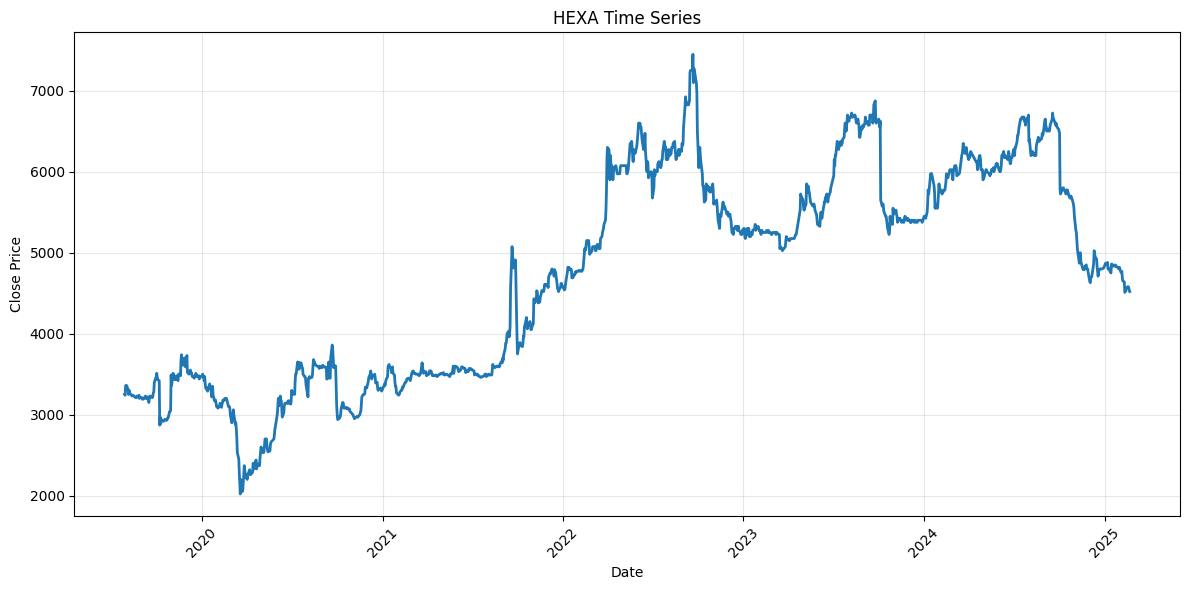

In [4]:
import matplotlib.pyplot as plt

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')

# Sort by date to ensure proper line plotting
df = df.sort_values('date')

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['close'], linewidth=2)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('HEXA Time Series')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Preprocess

## Data spliting

In [5]:
#Reshape agar menjadi array
df1 = df['close'].values.reshape(-1, 1)
df1

array([[3250.],
       [3240.],
       [3360.],
       ...,
       [4570.],
       [4530.],
       [4520.]], shape=(1355, 1))

In [6]:
#Split data menjadi training dan testing (80,20)
train_size = int(len(df1) * 0.8)
test_size = len(df1) - train_size
train, test = df1[0:train_size,:], df1[train_size:len(df1),:]
print(len(train), len(test))

1084 271


## Normalisasi Data

In [7]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Inisialisasi scaler
min_max_scaler = MinMaxScaler(feature_range=(0, 1))

# Fit-transform untuk train
train_scale = min_max_scaler.fit_transform(train)

# Transform untuk test
test_scale = min_max_scaler.transform(test)

# Konversi ke tabel (DataFrame) dengan nama kolom sama seperti data asli
train_scale_df = pd.DataFrame(train_scale, columns=['close'])
test_scale_df = pd.DataFrame(test_scale, columns=['close'])

train_scale_df.head()

,close
0,0.226519
1,0.224678
2,0.246777
3,0.246777
4,0.246777


In [8]:
scaling_training = pd.DataFrame(train_scale)
scaling_training.T.to_excel('scaling training.xlsx', index=False)

scaling_testing = pd.DataFrame(test_scale)
scaling_testing.T.to_excel('scaling testing.xlsx', index=False)

# Hyperparameter Tuning

## Fungsi BantuLag Tambahan

In [9]:
def create_dataset_with_extra_lags(data, lookback):
    X, y = [], []
    for i in range(lookback + 2, len(data)):
        seq = data[i - lookback:i]  # lookback window
        extra = np.array([data[i - 1], data[i - 2]])  # lag-1 & lag-2
        x = np.concatenate([seq, extra])
        X.append(x)
        y.append(data[i])
    return np.array(X), np.array(y)

## Fungsi Pembuat Model

In [10]:
def create_model(input_shape, hidden_neurons, learning_rate, dropout_rate=0.0):
    model = Sequential([
        Dense(hidden_neurons, activation='relu', input_shape=(input_shape,)),
        Dropout(dropout_rate),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return model

## Random Search Hyperparam

In [ ]:
# === 4. Search Space & Inisialisasi ===
param_space = {
    'lookback': [30, 50, 60],
    'hidden_neurons': [128, 256],
    'learning_rate': [0.0005, 0.0001, 0.00005],
    'dropout_rate': [0.1, 0.2, 0.3],
    'batch_size': [16, 32]
}
n_iter = 20

best_mse = float('inf')
best_params = None
best_model = None
best_scaler = None
history = []

print("🚀 Memulai Random Search...")

for _ in range(n_iter):
    # Sample hyperparameter
    lookback = random.choice(param_space['lookback'])
    hidden_neurons = random.choice(param_space['hidden_neurons'])
    learning_rate = random.choice(param_space['learning_rate'])
    dropout_rate = random.choice(param_space['dropout_rate'])
    batch_size = random.choice(param_space['batch_size'])

    print(f"\nMencoba: lookback={lookback}, neurons={hidden_neurons}, lr={learning_rate}, "
          f"dropout={dropout_rate}, batch={batch_size}")

    # Buat dataset
    # Use train_scale and test_scale instead of train_data and test_data
    X_train, y_train = create_dataset_with_extra_lags(train_scale.flatten(), lookback)
    if len(X_train) == 0:
        continue

    # Scaling X_train (fit only on X_train)
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    # y_train is already scaled from train_scale.flatten(), no need to scale it again with this scaler.

    # Input shape = lookback + 2 (karena tambah 2 lag)
    input_shape = lookback + 2
    model = create_model(input_shape, hidden_neurons, learning_rate, dropout_rate)

    # Pelatihan
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    model.fit(
        X_train_scaled, y_train,
        epochs=100,
        batch_size=batch_size,  # gunakan batch_size dari sampling
        verbose=0,
        callbacks=[early_stop]
    )

    # Evaluasi di test
    # Use test_scale instead of test_data
    X_test, y_test = create_dataset_with_extra_lags(test_scale.flatten(), lookback)
    if len(X_test) == 0:
        continue

    X_test_scaled = scaler.transform(X_test)
    y_pred_scaled = model.predict(X_test_scaled, verbose=0).flatten()

    # Kembalikan ke skala asli
    # y_test from create_dataset_with_extra_lags is already scaled (from test_scale.flatten())
    y_test_original = min_max_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = min_max_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    # Pastikan panjang sama (aman)
    min_len = min(len(y_test_original), len(y_pred_original))
    y_test_original = y_test_original[:min_len]
    y_pred_original = y_pred_original[:min_len]

    mse = mean_squared_error(y_test_original, y_pred_original)
    print(f"  → MSE: {mse:.4f}")

    history.append({
        'lookback': lookback,
        'hidden_neurons': hidden_neurons,
        'learning_rate': learning_rate,
        'dropout_rate': dropout_rate,
        'batch_size': batch_size,
        'mse': mse
    })

    if mse < best_mse:
        best_mse = mse
        best_params = {
            'lookback': lookback,
            'hidden_neurons': hidden_neurons,
            'learning_rate': learning_rate,
            'dropout_rate': dropout_rate,
            'batch_size': batch_size
        }
        best_model = model
        best_scaler = scaler

# === 5. Tampilkan Hasil Terbaik ===
print("\n" + "="*60)
print("✅ Hasil Terbaik dari Random Search:")
print(f"  MSE      : {best_mse:.4f}")
print(f"  Lookback : {best_params['lookback']}")
print(f"  Neurons  : {best_params['hidden_neurons']}")
print(f"  LR       : {best_params['learning_rate']}")
print(f"  Dropout  : {best_params['dropout_rate']}")
print(f"  Batch    : {best_params['batch_size']}")
print("="*60)

🚀 Memulai Random Search...


NameError: name 'random' is not defined